### Section 10.3, Conduction de la chaleur avec une source nucléaire

>Cet exemple est assez complexe, il sera très utile tant sur le plan de l'application des bilans thermiques que dans l'utilisation de sympy pour effectuer le travail de solution mathématiques et des manipulations algébriques. Les développements faits dans Transport Phenomena sont reproduits fidèlement ici.
La figure suivante extraite de Transport Phenomena illustre le problème à traiter. Utilisez le livre pour suivre les développements en détail, les solutions effectuées avec **sympy** utilisent des noms de constantes d'intégration différentes, on les renomme dans le **notebook** pour garder la similarité entre les solutions.
<img src='Chap-10-Section10-3.png'>
Cet exemple peut servir de base à tout autre problème de conduction de chaleur en présence de génération de chaleur, que ce soit par réaction chimique ou biochimique, source électrique ou magnétique.

Voyons dans ce qui suit un résumé de l'analyse nécessaire pour obtenir les profils de flux thermiques et de température:

In [10]:
from IPython.display import IFrame
IFrame("GCH200_Ch10_3_resume.pdf", width=760, height=480, zoom=1)

>Maintenant regardons comment on procède en utilisant le calcul formel de sympy pour effectuer les manipulations, intégrales, solutions d'équations différentielles et recherche des constantes provenant des conditions aux limites. On terminera en tracant un profil de température dans les deux milieux.

In [11]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)

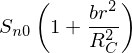

In [12]:
# Paramètres, variables et fonctions
S_n,r,b,R_F,R_C,S_n0,delta_r=sp.symbols('S_n,r,b,R_F,R_C,S_n0,delta_r')                                                            
k_C,k_F=sp.symbols('k_C,k_F')             
q_F=sp.symbols('q_F')           # Notation de Transport Phenomena
T_F=sp.Function('T_F')(r) 
q_C=sp.symbols('q_C')
T_C=sp.Function('T_C')(r)
S_n=S_n0*(1+b*(r/R_C)**2)
display(S_n)

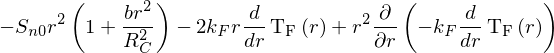

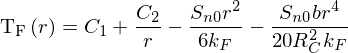

In [13]:
#
# Résultat du bilan dans la sphère fissible d'uranium, solution
#
eqF=(sp.diff(q_F(r)*r**2,r)-S_n*r**2)
# On substitue la loi de Fourier pour trouver le profil de température
eq_TF=eqF.subs(q_F(r),-k_F*sp.diff(T_F,r))
display(eq_TF)
T_F=sp.dsolve(eq_TF,T_F)
display( T_F)

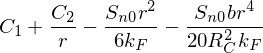

In [14]:
T_F=T_F.rhs # Voyez ci-dessous pourquoi on utilise .rhs (right hand side) de l'expression
display(T_F)
q_F=-k_F*sp.diff(T_F,r)

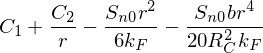

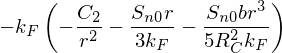

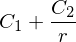

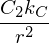

In [15]:
#
# Bilan dans l'aluminium, la solution est plus simple évidemment car il n'y a pas de source
#
eqC=sp.diff(q_C(r)*r**2,r)
eq_TC=eqC.subs(q_C(r),-k_C*sp.diff(T_C,r))
T_C=sp.dsolve(eq_TC,T_C)
T_C=T_C.rhs
q_C=-k_C*sp.diff(T_C,r)
display(T_F)
display(q_F)
display(T_C)
display(q_C)

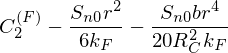

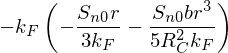

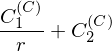

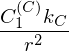

In [16]:
#
# Les noms des constantes doivent être changés car sympy a réutilisé les noms C1 et C2 dans les 2 régions.
# Remarquez en plus que la nomenclature 1 et 2 est inversée par rapport au livre.
#
# Pour comparaison, on utilisera les mêmes noms que dans Transport Phenomena, ainsi
#  C_1 de l'uranium devient C_2^(F), C_1 de l'alu devient C_2^(F), etc...
# 
T_F=T_F.subs(sp.symbols('C1'),sp.symbols('C_2^(F)'))
T_F=T_F.subs(sp.symbols('C2'),sp.symbols('C_1^(F)'))
q_F=q_F.subs(sp.symbols('C2'),sp.symbols('C_1^(F)'))
T_C=T_C.subs(sp.symbols('C1'),sp.symbols('C_2^(C)'))
T_C=T_C.subs(sp.symbols('C2'),sp.symbols('C_1^(C)'))
q_C=q_C.subs(sp.symbols('C2'),sp.symbols('C_1^(C)'))
#
# Maintenant on peut commencer à appliquer les conditions aux limites. 
# La conditions au centre est que le flux ne peut être infini, donc C_1^(F) doit être nul
# On effectue donc:
q_F=q_F.subs(sp.symbols('C_1^(F)'),0)
T_F=T_F.subs(sp.symbols('C_1^(F)'),0)
display(T_F)
display(q_F)
display(T_C)
display(q_C)

>Comparons les équations obtenues avec le texte:
<img src='GCH200-Section-10-3-1.png'>
<img src='GCH200-Section-10-3-2.png'>
>Pour les 3 constantes qui restent on a 3 conditions qui sont: à l'interface entre l'aluminium et l'uranium, les températures et les flux sont égaux, donc $q_A = q_U$, en $ r= R_F $ et $T_A = T_U$, en $ r= R_F $  et en $ r = R_C $, $T_A = T_0$.
En principe on pourrait simplement résoudre directement ces 3 équations à 3 inconnues, mais les équations présentées ci-haut nous montrent que la solution algébrique peut être faite en trois parties, c'est ce qu'on choisit ici:

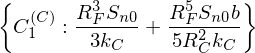

In [18]:
#
# La constante C_1^(C) est trouvée en posant les deux flux égaux à l'interface en r=R_F
#
eq=sp.Eq(q_F.subs(r,R_F)-q_C.subs(r,R_F),0)
constante=sp.solve(eq,sp.symbols('C_1^(C)'),dict=True)
display(constante[0])
T_C=T_C.subs(constante[0])
q_C=q_C.subs(constante[0])

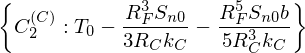

In [10]:
#
# La constante C4 peut maintenant être trouvée car la température en r=RC est T0
#
T_0=sp.symbols('T_0')
eq=sp.Eq(T_C.subs(r,R_C)-T_0)
constante=sp.solve((eq,0),sp.symbols('C_2^(C)'))
T_C=T_C.subs(constante)
display(constante)

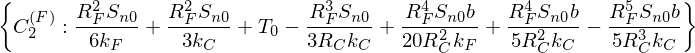

In [11]:
#
# Il ne reste plus maintenant qu'à trouver C_2^(F) dans T_U qui sera trouvé en égalisant T_A et T_U
# en r=R_F
#
eq=sp.Eq(T_F.subs(r,R_F)-T_C.subs(r,R_F))
constante=sp.solve((eq,0),sp.symbols('C_2^(F)'))
display(constante)

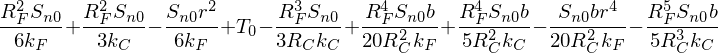

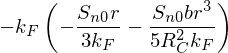

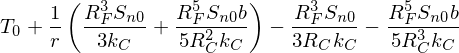

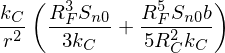

In [12]:
T_F=T_F.subs(constante)
display(T_F)
display(q_F)
display(T_C)
display(q_C)

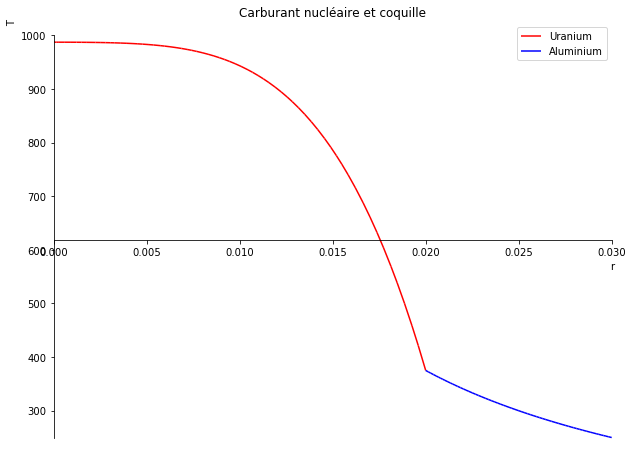

In [14]:
### Comparer avec le profil montré sur la figure 10.3-1
dico={'k_F':22,'k_C':140,'b':100,'R_F':0.02,'R_C':0.025,'S_n0':1e7,'T_0':300}
T_Fplot=T_F.subs(dico)
T_Cplot=T_C.subs(dico)
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=10,8
p = sp.plot((T_Fplot,(r,0,0.02)),(T_Cplot,(r,0.02,0.03))
            ,legend=True,xlabel='r',ylabel='T'
            , title='Carburant nucléaire et coquille', show=False) 
p[0].line_color = 'red'
p[0].label='Uranium'
p[1].line_color = 'blue'
p[1].label='Aluminium'
p.show()